In [1]:
from module import *
T0 = 18
SHIFT = 24 - T0

In [32]:
table_info("minute_sleep")

nrows: 198559
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Id      5 non-null      float64
 1   date    5 non-null      str    
 2   value   5 non-null      int64  
 3   logId   5 non-null      float64
dtypes: float64(2), int64(1), str(1)
memory usage: 292.0 bytes


,Id,date,value,logId
0,1.503960e+09,3/13/2016 2:39:30 AM,1,1.111492e+10
1,1.503960e+09,3/13/2016 2:40:30 AM,1,1.111492e+10
2,1.503960e+09,3/13/2016 2:41:30 AM,1,1.111492e+10
3,1.503960e+09,3/13/2016 2:42:30 AM,1,1.111492e+10
4,1.503960e+09,3/13/2016 2:43:30 AM,1,1.111492e+10


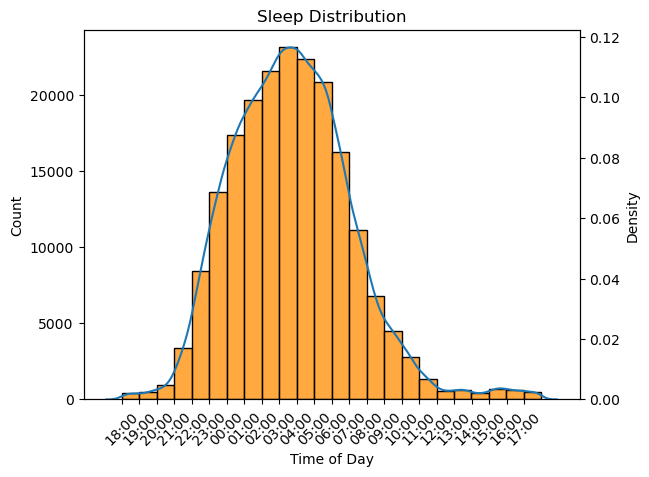

In [64]:
minute_sleep = pd.read_sql("SELECT * FROM minute_sleep", conn)
dates = pd.to_datetime(minute_sleep['date'], format=DATE_FMT)
time = (dates.dt.hour + SHIFT) % 24 + dates.dt.minute / 60
fig, ax1 = plt.subplots()
sns.histplot(time, binwidth=1, color="darkorange", ax=ax1)
ax2 = ax1.twinx()
sns.kdeplot(time, ax=ax2)
ax1.set_xticks(range(24), labels=[f"{h:02d}:00" for h in np.roll(range(24), SHIFT)], rotation=45)
ax1.set_xlabel('Time of Day')
plt.title("Sleep Distribution")
plt.show()

# Bedtime & Duration

In [2]:
bedtimes = pd.read_sql("SELECT *, COUNT(*) AS minutes FROM minute_sleep GROUP BY logId", conn, index_col='logId')
bedtimes['date'] = pd.to_datetime(bedtimes['date'], format=DATE_FMT)
bedtimes

,Id,date,value,minutes
logId,,,,
1.110365e+10,6.962181e+09,2016-03-11 23:29:00,2,430
1.110371e+10,6.117666e+09,2016-03-11 22:42:30,1,358
1.110373e+10,2.026352e+09,2016-03-11 21:31:30,1,544
1.110374e+10,2.347168e+09,2016-03-11 23:43:00,3,436
1.110404e+10,4.445115e+09,2016-03-12 02:43:30,2,210
...,...,...,...,...
1.137262e+10,6.962181e+09,2016-04-12 00:23:30,1,387
1.137309e+10,8.378563e+09,2016-04-11 22:19:00,2,356
1.137474e+10,4.445115e+09,2016-04-12 01:44:00,1,332


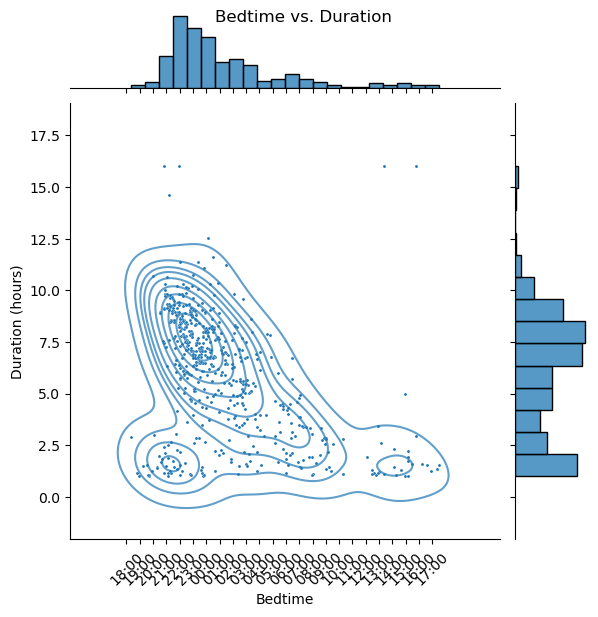

In [7]:
shifted_time = (bedtimes['date'].dt.hour + SHIFT) % 24 + bedtimes['date'].dt.minute / 60 + bedtimes['date'].dt.second / 60**2
Duration = bedtimes['minutes'] / 60
g = sns.jointplot(x=shifted_time, y=Duration, s=5)
g.plot_joint(sns.kdeplot, alpha=0.7, label='Sleep Duration')
g.ax_joint.set(xlabel='Bedtime', ylabel="Duration (hours)")
g.ax_joint.set_xticks(range(24), rotation=45, labels=[f"{h:02d}:00" for h in np.roll(range(24), SHIFT)])
plt.suptitle("Bedtime vs. Duration")
plt.show()